In [23]:
# Cell 1: Imports & Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on", device)

Running on cuda


In [24]:
# Cell 2: Load data and create train/val loaders
data_path = "../data/raw_chunks.pt"  # adjust path as needed
X, y = torch.load(data_path)  # X: [N,27,9], y: [N]
num_classes = 5

# wrap in a TensorDataset
ds = TensorDataset(X, y)

# stratified-ish split: 80% train, 20% val
n_total = len(ds)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = random_split(
    ds, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)

batch_size = 64
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, drop_last=False
)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

Train samples: 24248, Val samples: 6063


In [25]:
# Cell 3: Model Definitions


# 1D CNN for sequence of 9 features over 27 timesteps
class CNN1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),  # → seq_len=13
            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # → [B,64,1]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: [B,27,9] → [B,9,27]
        x = x.permute(0, 2, 1)
        x = self.encoder(x)
        return self.classifier(x)


# 2D CNN treating chunk as a 27×9 “image”
class CNN2D(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # → [B,16,13,4]
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # → [B,32,1,1]
        )
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        # x: [B,27,9] → [B,1,27,9]
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# Bi-directional LSTM
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=9, hidden_dim=64, num_layers=2, num_classes=10):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: [B,27,9]
        _, (h_n, _) = self.lstm(x)
        # h_n: [2*num_layers, B, hidden_dim]
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(h)


# Transformer Classifier
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1,max_len,d_model]

    def forward(self, x):
        # x: [B,seq_len,d_model]
        return x + self.pe[:, : x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=9, d_model=64, nhead=8, num_layers=3, num_classes=10):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=27)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc_out = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [B,27,9] → [B,27,d_model]
        x = self.fc_in(x)
        x = self.pos(x)
        # → [seq_len, B, d_model]
        x = x.permute(1, 0, 2)
        enc = self.encoder(x)
        # mean‐pool over seq
        out = enc.mean(dim=0)  # [B, d_model]
        return self.fc_out(out)

In [26]:
# Cell 4: Training loop with Early Stopping
import copy
import torch
import torch.nn as nn
import torch.optim as optim


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=5,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # — Training —
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1)
            running_corrects += (preds == yb).sum().item()
            total += Xb.size(0)

        train_loss = running_loss / total
        train_acc = running_corrects / total

        # — Validation —
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv, yv = Xv.to(device), yv.to(device)
                logits = model(Xv)
                loss = criterion(logits, yv)
                val_loss += loss.item() * Xv.size(0)
                val_corrects += (logits.argmax(dim=1) == yv).sum().item()
                val_total += Xv.size(0)

        val_loss = val_loss / val_total
        val_acc = val_corrects / val_total

        print(
            f"[{epoch:02d}/{epochs}] "
            f"Train: loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f" Val: loss={val_loss:.4f}, acc={val_acc:.4f}"
        )

        # — Early Stopping Check —
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            print(
                f"  ↳ no improvement for {patience_counter}/{early_stopping_patience} epochs"
            )
            if patience_counter >= early_stopping_patience:
                print(f"🛑 Early stopping at epoch {epoch}")
                break

    # load best weights before returning
    model.load_state_dict(best_model_wts)
    return model

In [27]:
# Cell 5: Train the 1D CNN with Early Stopping, then save
model_1d = CNN1D(in_channels=X.shape[2], num_classes=num_classes)
trained_1d = train_model(
    model_1d,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=5,
)

# Save best 1D‐CNN
import os

os.makedirs("artifacts", exist_ok=True)
torch.save(trained_1d.state_dict(), "artifacts/cnn1d.pth")
print("✅ Saved CNN1D weights to artifacts/cnn1d.pth")

[01/10] Train: loss=0.1548, acc=0.9811 |  Val: loss=0.0067, acc=1.0000
[02/10] Train: loss=0.0120, acc=0.9995 |  Val: loss=0.0014, acc=1.0000
[03/10] Train: loss=0.0056, acc=0.9998 |  Val: loss=0.0005, acc=1.0000
[04/10] Train: loss=0.0033, acc=0.9998 |  Val: loss=0.0002, acc=1.0000
[05/10] Train: loss=0.0028, acc=0.9997 |  Val: loss=0.0002, acc=1.0000
[06/10] Train: loss=0.0023, acc=0.9998 |  Val: loss=0.0001, acc=1.0000
[07/10] Train: loss=0.0019, acc=0.9999 |  Val: loss=0.0001, acc=1.0000
[08/10] Train: loss=0.0017, acc=0.9998 |  Val: loss=0.0001, acc=1.0000
  ↳ no improvement for 1/5 epochs
[09/10] Train: loss=0.0014, acc=0.9998 |  Val: loss=0.0000, acc=1.0000
[10/10] Train: loss=0.0015, acc=0.9998 |  Val: loss=0.0000, acc=1.0000
  ↳ no improvement for 1/5 epochs
✅ Saved CNN1D weights to artifacts/cnn1d.pth


In [28]:
# Cell 6: Train the 2D CNN with Early Stopping, then save
model_2d = CNN2D(num_classes=num_classes)
trained_2d = train_model(
    model_2d,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=5,
)

# Save best 2D‐CNN
torch.save(trained_2d.state_dict(), "artifacts/cnn2d.pth")
print("✅ Saved CNN2D weights to artifacts/cnn2d.pth")

[01/10] Train: loss=0.3153, acc=0.9691 |  Val: loss=0.0187, acc=1.0000
[02/10] Train: loss=0.0043, acc=1.0000 |  Val: loss=0.0009, acc=1.0000
[03/10] Train: loss=0.0005, acc=1.0000 |  Val: loss=0.0003, acc=1.0000
[04/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0002, acc=1.0000
[05/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[06/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[07/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[08/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
  ↳ no improvement for 1/5 epochs
[09/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[10/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
  ↳ no improvement for 1/5 epochs
✅ Saved CNN2D weights to artifacts/cnn2d.pth


In [29]:
# Cell 7: Train the LSTM with Early Stopping, then save
model_lstm = LSTMClassifier(
    input_dim=X.shape[2], hidden_dim=64, num_layers=2, num_classes=num_classes
)
trained_lstm = train_model(
    model_lstm,
    train_loader,
    val_loader,
    epochs=10,
    lr=5e-4,
    weight_decay=1e-5,
    early_stopping_patience=5,
)

# Save best LSTM
torch.save(trained_lstm.state_dict(), "artifacts/lstm.pth")
print("✅ Saved LSTM weights to artifacts/lstm.pth")

[01/10] Train: loss=0.1521, acc=0.9637 |  Val: loss=0.0017, acc=1.0000
[02/10] Train: loss=0.0012, acc=1.0000 |  Val: loss=0.0006, acc=1.0000
[03/10] Train: loss=0.0004, acc=1.0000 |  Val: loss=0.0003, acc=1.0000
[04/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0002, acc=1.0000
[05/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[06/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[07/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[08/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[09/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[10/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0000, acc=1.0000
✅ Saved LSTM weights to artifacts/lstm.pth


In [30]:
# Cell 8: Train the Transformer with Early Stopping, then save
model_transformer = TransformerClassifier(
    input_dim=X.shape[2], d_model=64, nhead=8, num_layers=3, num_classes=num_classes
)
trained_transformer = train_model(
    model_transformer,
    train_loader,
    val_loader,
    epochs=10,
    lr=5e-4,
    weight_decay=1e-5,
    early_stopping_patience=5,
)

# Save best Transformer
torch.save(trained_transformer.state_dict(), "artifacts/transformer.pth")
print("✅ Saved Transformer weights to artifacts/transformer.pth")

c:\Users\SakifKhan\bleh\ids\Intrusion-Detection-System-Using-CNN-and-Transfer-Learning\ids\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[01/10] Train: loss=0.0565, acc=0.9861 |  Val: loss=0.0023, acc=1.0000
[02/10] Train: loss=0.0017, acc=1.0000 |  Val: loss=0.0008, acc=1.0000
[03/10] Train: loss=0.0007, acc=1.0000 |  Val: loss=0.0004, acc=1.0000
[04/10] Train: loss=0.0004, acc=1.0000 |  Val: loss=0.0002, acc=1.0000
[05/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0002, acc=1.0000
[06/10] Train: loss=0.0002, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[07/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[08/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[09/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0001, acc=1.0000
[10/10] Train: loss=0.0001, acc=1.0000 |  Val: loss=0.0000, acc=1.0000
✅ Saved Transformer weights to artifacts/transformer.pth


# Test


In [31]:
# ── Block 3: Load full raw-chunk dataset & build test DataLoader ──────────
X_tensor, y_tensor = torch.load("../data/raw_chunks.pt")  # adjust path if needed
print(f"Loaded {X_tensor.size(0)} samples of shape {tuple(X_tensor.shape[1:])}")
num_classes = int(torch.unique(y_tensor).numel())
print(f"Number of classes: {num_classes}")

test_ds = TensorDataset(X_tensor, y_tensor)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Loaded 30311 samples of shape (27, 9)
Number of classes: 5


In [32]:
# ── Block 4: Evaluation helper ─────────────────────────────────────────────
def evaluate(model, loader):
    model.to(device).eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())
    print(classification_report(all_labels, all_preds, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

In [33]:
# ── Block 5: Test 1D-CNN ────────────────────────────────────────────────────
model_1d = CNN1D(in_channels=X_tensor.size(2), num_classes=num_classes)
model_1d.load_state_dict(torch.load("artifacts/cnn1d.pth", map_location=device))
print("=== 1D-CNN Results ===")
evaluate(model_1d, test_loader)

=== 1D-CNN Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1092
           1       1.00      1.00      1.00       912
           2       1.00      1.00      1.00     25993
           3       1.00      1.00      1.00      1205
           4       1.00      1.00      1.00      1109

    accuracy                           1.00     30311
   macro avg       1.00      1.00      1.00     30311
weighted avg       1.00      1.00      1.00     30311

Confusion Matrix:
[[ 1092     0     0     0     0]
 [    0   912     0     0     0]
 [    0     0 25993     0     0]
 [    0     0     0  1205     0]
 [    0     0     0     0  1109]]


In [34]:
# ── Block 6: Test 2D-CNN ────────────────────────────────────────────────────
model_2d = CNN2D(num_classes=num_classes)
model_2d.load_state_dict(torch.load("artifacts/cnn2d.pth", map_location=device))
print("=== 2D-CNN Results ===")
evaluate(model_2d, test_loader)

=== 2D-CNN Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1092
           1       1.00      1.00      1.00       912
           2       1.00      1.00      1.00     25993
           3       1.00      1.00      1.00      1205
           4       1.00      1.00      1.00      1109

    accuracy                           1.00     30311
   macro avg       1.00      1.00      1.00     30311
weighted avg       1.00      1.00      1.00     30311

Confusion Matrix:
[[ 1092     0     0     0     0]
 [    0   912     0     0     0]
 [    0     0 25993     0     0]
 [    0     0     0  1205     0]
 [    0     0     0     0  1109]]


In [35]:
# ── Block 7: Test LSTM ──────────────────────────────────────────────────────
model_lstm = LSTMClassifier(
    input_dim=X_tensor.size(2), hidden_dim=64, num_layers=2, num_classes=num_classes
)
model_lstm.load_state_dict(torch.load("artifacts/lstm.pth", map_location=device))
print("=== LSTM Results ===")
evaluate(model_lstm, test_loader)

=== LSTM Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1092
           1       1.00      1.00      1.00       912
           2       1.00      1.00      1.00     25993
           3       1.00      1.00      1.00      1205
           4       1.00      1.00      1.00      1109

    accuracy                           1.00     30311
   macro avg       1.00      1.00      1.00     30311
weighted avg       1.00      1.00      1.00     30311

Confusion Matrix:
[[ 1092     0     0     0     0]
 [    0   912     0     0     0]
 [    0     0 25993     0     0]
 [    0     0     0  1205     0]
 [    0     0     0     0  1109]]


In [36]:
# ── Block 8: Test Transformer ───────────────────────────────────────────────
model_tf = TransformerClassifier(
    input_dim=X_tensor.size(2),
    d_model=64,
    nhead=8,
    num_layers=3,
    num_classes=num_classes,
)
model_tf.load_state_dict(torch.load("artifacts/transformer.pth", map_location=device))
print("=== Transformer Results ===")
evaluate(model_tf, test_loader)

=== Transformer Results ===


c:\Users\SakifKhan\bleh\ids\Intrusion-Detection-System-Using-CNN-and-Transfer-Learning\ids\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1092
           1       1.00      1.00      1.00       912
           2       1.00      1.00      1.00     25993
           3       1.00      1.00      1.00      1205
           4       1.00      1.00      1.00      1109

    accuracy                           1.00     30311
   macro avg       1.00      1.00      1.00     30311
weighted avg       1.00      1.00      1.00     30311

Confusion Matrix:
[[ 1092     0     0     0     0]
 [    0   912     0     0     0]
 [    0     0 25993     0     0]
 [    0     0     0  1205     0]
 [    0     0     0     0  1109]]


In [37]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# define models and their saved weights
models = {
    "1D-CNN": (
        CNN1D(in_channels=X_tensor.size(2), num_classes=num_classes),
        "artifacts/cnn1d.pth",
    ),
    "2D-CNN": (CNN2D(num_classes=num_classes), "artifacts/cnn2d.pth"),
    "LSTM": (
        LSTMClassifier(
            input_dim=X_tensor.size(2),
            hidden_dim=64,
            num_layers=2,
            num_classes=num_classes,
        ),
        "artifacts/lstm.pth",
    ),
    "Transformer": (
        TransformerClassifier(
            input_dim=X_tensor.size(2),
            d_model=64,
            nhead=8,
            num_layers=3,
            num_classes=num_classes,
        ),
        "artifacts/transformer.pth",
    ),
}

results = []
for name, (model, path) in models.items():
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device).eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    results.append({"model": name, "accuracy": acc, "f1_macro": f1})

# display comparison
df_results = (
    pd.DataFrame(results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)
print(df_results)

best = df_results.iloc[0]
print(
    f"\nBest model: {best['model']} (accuracy={best['accuracy']:.4f}, f1_macro={best['f1_macro']:.4f})"
)

c:\Users\SakifKhan\bleh\ids\Intrusion-Detection-System-Using-CNN-and-Transfer-Learning\ids\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


         model  accuracy  f1_macro
0       1D-CNN       1.0       1.0
1       2D-CNN       1.0       1.0
2         LSTM       1.0       1.0
3  Transformer       1.0       1.0

Best model: 1D-CNN (accuracy=1.0000, f1_macro=1.0000)


C:\Users\SakifKhan\AppData\Local\Temp\ipykernel_22204\243556089.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=sorted_df, ax=axes[0, 0], palette="Blues_d")
C:\Users\SakifKhan\AppData\Local\Temp\ipykernel_22204\243556089.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1 Score", y="Model", data=sorted_df, ax=axes[0, 1], palette="Greens_d")
C:\Users\SakifKhan\AppData\Local\Temp\ipykernel_22204\243556089.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\SakifKhan\AppData\Local\Temp\ipyker

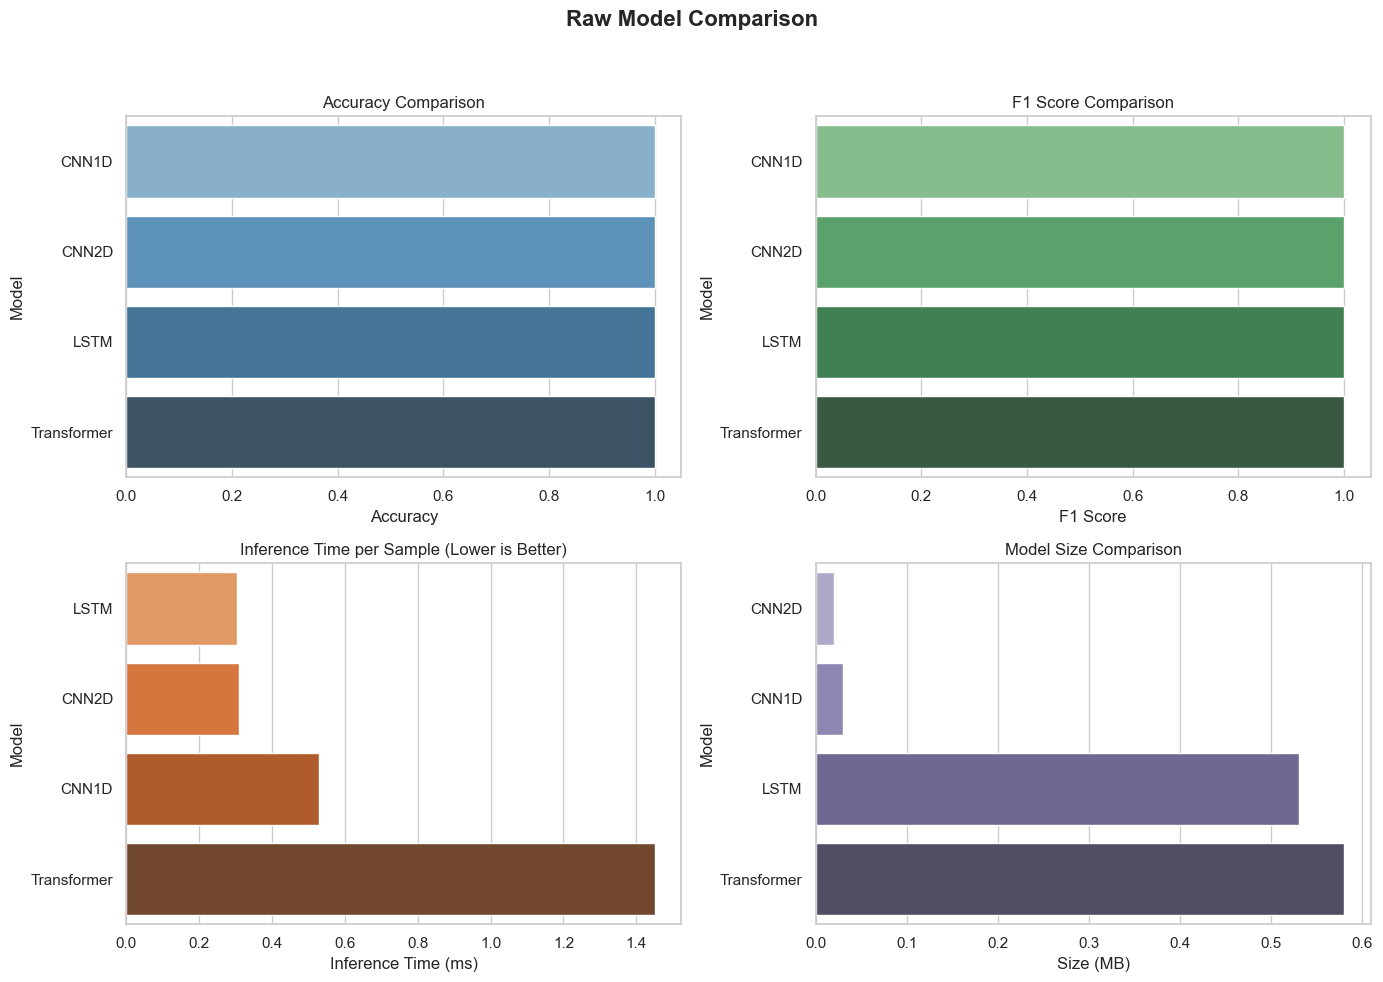

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Raw Model Comparison", fontsize=16, fontweight="bold")

# Accuracy subplot
sorted_df = df_raw_results.sort_values("Accuracy", ascending=False)
sns.barplot(x="Accuracy", y="Model", data=sorted_df, ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Accuracy Comparison")
axes[0, 0].set_xlabel("Accuracy")
axes[0, 0].set_ylabel("Model")

# F1 Score subplot
sorted_df = df_raw_results.sort_values("F1 Score", ascending=False)
sns.barplot(x="F1 Score", y="Model", data=sorted_df, ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("F1 Score Comparison")
axes[0, 1].set_xlabel("F1 Score")
axes[0, 1].set_ylabel("Model")

# Inference Time subplot
sorted_df = df_raw_results.sort_values("Inference Time (ms)", ascending=True)
sns.barplot(
    x="Inference Time (ms)",
    y="Model",
    data=sorted_df,
    ax=axes[1, 0],
    palette="Oranges_d",
)
axes[1, 0].set_title("Inference Time per Sample (Lower is Better)")
axes[1, 0].set_xlabel("Inference Time (ms)")
axes[1, 0].set_ylabel("Model")

# Model Size subplot
sorted_df = df_raw_results.sort_values("Size (MB)", ascending=True)
sns.barplot(
    x="Size (MB)", y="Model", data=sorted_df, ax=axes[1, 1], palette="Purples_d"
)
axes[1, 1].set_title("Model Size Comparison")
axes[1, 1].set_xlabel("Size (MB)")
axes[1, 1].set_ylabel("Model")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Benchmarking ---


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.quantization as quant


# ── best model ─────────────────────────────────────────────
class CNN2D(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # [B,1,27,9]
        x = self.conv(x)  # [B,32,1,1]
        return self.fc(x.view(x.size(0), -1))

In [45]:
device = torch.device("cpu")
model = CNN2D(num_classes=5).to(device).eval()
ckpt = torch.load("artifacts/cnn2d.pth", map_location=device)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [46]:
# collect parameters to prune:
to_prune = [
    (m, "weight") for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))
]

prune.global_unstructured(
    to_prune, pruning_method=prune.L1Unstructured, amount=0.30  # prune 30% of weights
)
# make pruning permanent
for m, name in to_prune:
    prune.remove(m, name)
print("✅ Pruning done (30%)")

✅ Pruning done (30%)


In [47]:
quantized_model = quant.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
quantized_model.eval()
print("✅ Dynamic quantization applied")

✅ Dynamic quantization applied


In [48]:
# 1) Fuse conv+relu:
model_fused = torch.quantization.fuse_modules(
    model, [["conv.0", "conv.1"], ["conv.3", "conv.4"]]
)

# 2) Set QConfig & prepare:
model_fused.qconfig = quant.get_default_qconfig("fbgemm")
model_prepared = quant.prepare(model_fused)

# 3) Calibrate on a few samples (use real data if possible):
dummy = torch.randn(16, 27, 9)  # batch of 16
with torch.no_grad():
    model_prepared(dummy)

# 4) Convert to static quant:
model_static = quant.convert(model_prepared)
model_static.eval()
print("✅ Static quantization done")

✅ Static quantization done


c:\Users\SakifKhan\bleh\ids\Intrusion-Detection-System-Using-CNN-and-Transfer-Learning\ids\Lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [49]:
os.makedirs("artifacts", exist_ok=True)

# 6.1 Pruned (float)
torch.save(model.state_dict(), "artifacts/cnn2d_pruned.pth")
print(
    "Pruned state_dict size:", os.path.getsize("artifacts/cnn2d_pruned.pth") / 1e6, "MB"
)

# 6.2 Dynamic-quantized
torch.save(quantized_model.state_dict(), "artifacts/cnn2d_quant_dynamic.pth")
print(
    "Dynamic quant state size:",
    os.path.getsize("artifacts/cnn2d_quant_dynamic.pth") / 1e6,
    "MB",
)

# 6.3 Static-quantized (scripted)
scripted_static = torch.jit.script(model_static.to("cpu"))
scripted_static.save("artifacts/cnn2d_quant_static.pt")
print(
    "Static quant scripted size:",
    os.path.getsize("artifacts/cnn2d_quant_static.pt") / 1e6,
    "MB",
)

Pruned state_dict size: 0.023057 MB
Dynamic quant state size: 0.023349 MB
Static quant scripted size: 0.02757 MB
